# Cross-Market Correlation Strategy: BTC & NASDAQ Futures


# 1. Project Understanding

## 1.1 Project Objective and Approach
This project aims to enhance the performance of a systematic trading strategy through the application of machine-learning techniques. A "baseline" rule-based strategy is first evaluated using historical backtesting to establish benchmark performance. Its limitations are then systematically analyzed, after which an appropriate machine-learning model is applied to address the identified weaknesses. The effectiveness of the proposed approach is evaluated by comparing trading performance before and after the integration of machine learning.

## 1.2 Hypothesis Definition
At short intraday time scales, directional agreement between Bitcoin (BTC) and NASDAQ-100 (NQ) futures reflects more stable market conditions, whereas directional divergence indicates increased market uncertainty and reduced trend persistence.


# 2. Data Understanding and Preparation

Goal: Explore, diagnose, and validate the raw data.

## 2.1 Data Sources and Structure
- **Assets:** BTCUSDT Perpetual Futures, NASDAQ-100 E-mini Futures  
- **Interval:** 1-minute OHLCV  
- **Period:** [start date] – [end date]  
- **Source:** TradingView
- **Columns:** timestamp, open, high, low, close, volume  
- **Market structure:** BTC trades 24/7, NQ trades during CME sessions

## 2.2 Timestamp Handling and Synchronization
0. Read and inspect CSVs

In [34]:
import pandas as pd

# Assuming 'Datasets' folder is in the same directory as the notebook
btc = pd.read_csv("Datasets/btc_raw_data.csv", sep=',')
nq  = pd.read_csv("Datasets/nq_raw_data.csv", sep=',')

# Inspect columns 
print("BTC Columns:", btc.columns)
print("BTC Head:\n", btc.head())
print("Total BTC rows:", len(btc))

print("\nNQ Columns:", nq.columns)
print("NQ Head:\n", nq.head())
print("Total NQ rows:", len(nq))


BTC Columns: Index(['time', 'open', 'high', 'low', 'close', 'Volume'], dtype='object')
BTC Head:
          time     open     high      low    close  Volume
0  1764435900  90947.1  90947.1  90894.7  90913.6  32.829
1  1764435960  90913.6  90913.6  90877.3  90878.3  21.132
2  1764436020  90878.3  90879.1  90845.4  90849.2  29.737
3  1764436080  90849.2  90857.8  90819.8  90822.6  33.287
4  1764436140  90822.6  90830.0  90800.0  90830.0  39.433
Total BTC rows: 11874

NQ Columns: Index(['time', 'open', 'high', 'low', 'close', 'Volume'], dtype='object')
NQ Head:
          time      open      high       low     close  Volume
0  1764543600  25482.50  25546.00  25457.50  25514.00     746
1  1764543660  25512.75  25518.75  25494.75  25497.75     388
2  1764543720  25496.75  25509.50  25488.00  25493.25     412
3  1764543780  25494.00  25495.00  25471.25  25476.50     400
4  1764543840  25475.50  25494.75  25471.25  25475.00     292
Total NQ rows: 6900


1. Convert timestamps to datetime
2. Align both assets to the same timezone (UTC+1 / Polish time)
3. Synchronize datasets on common timestamps
4. Prepare the merged DataFrame for further analysis

In [35]:
# Convert UNIX epoch to datetime (assume UTC)
btc['timestamp'] = pd.to_datetime(btc['time'], unit='s', utc=True)
nq['timestamp']  = pd.to_datetime(nq['time'], unit='s', utc=True)

# Optional: convert to local time (Polish time UTC+1)
btc['timestamp'] = btc['timestamp'].dt.tz_convert('Europe/Warsaw')
nq['timestamp']  = nq['timestamp'].dt.tz_convert('Europe/Warsaw')

# Set timestamp as index
btc.set_index('timestamp', inplace=True)
nq.set_index('timestamp', inplace=True)

# Sort by timestamp just in case
btc.sort_index(inplace=True)
nq.sort_index(inplace=True)

# Keep only common timestamps for synchronized analysis
common_index = btc.index.intersection(nq.index)
btc_sync = btc.loc[common_index]
nq_sync  = nq.loc[common_index]

print("BTC synchronized head:\n", btc_sync.head())
print("NQ synchronized head:\n", nq_sync.head())
print("Total synchronized rows:", len(common_index))

print(btc_sync)
print(nq_sync.head)

BTC synchronized head:
                                  time     open     high      low    close  \
timestamp                                                                   
2025-12-01 00:00:00+01:00  1764543600  91179.0  91213.2  91103.9  91178.3   
2025-12-01 00:01:00+01:00  1764543660  91178.4  91210.1  91178.4  91193.8   
2025-12-01 00:02:00+01:00  1764543720  91193.8  91194.0  91103.4  91103.4   
2025-12-01 00:03:00+01:00  1764543780  91103.4  91106.2  91050.3  91067.3   
2025-12-01 00:04:00+01:00  1764543840  91067.2  91067.2  90999.0  91003.4   

                            Volume  
timestamp                           
2025-12-01 00:00:00+01:00  131.271  
2025-12-01 00:01:00+01:00   30.878  
2025-12-01 00:02:00+01:00   30.903  
2025-12-01 00:03:00+01:00   56.524  
2025-12-01 00:04:00+01:00   93.806  
NQ synchronized head:
                                  time      open      high       low     close  \
timestamp                                                                

## 2.3 Data Quality Checks

In [36]:
# 1. Check for missing values
print("Missing values per column:\n", returns.isna().sum())

# 2. Check for duplicated timestamps
print("Number of duplicated timestamps:", returns.index.duplicated().sum())

# 3. Basic descriptive statistics
print("Descriptive statistics:\n", returns.describe())

# 4. Outlier detection (optional: z-score > 4)
from scipy.stats import zscore

z_scores = np.abs(zscore(returns))
outliers = (z_scores > 4).sum()
print("Number of extreme outliers:", outliers)

Missing values per column:
 BTC_return    0
NQ_return     0
dtype: int64
Number of duplicated timestamps: 0
Descriptive statistics:
          BTC_return     NQ_return
count  8.205000e+03  8.205000e+03
mean  -7.796385e-07  4.648566e-07
std    7.632825e-04  2.296207e-04
min   -4.849125e-03 -2.080638e-03
25%   -4.009595e-04 -9.699697e-05
50%    2.166566e-06  0.000000e+00
75%    3.941875e-04  9.741082e-05
max    6.525574e-03  2.022855e-03
Number of extreme outliers: 100


In [44]:
#OPTIONAL: Save final datasets
save_final = True  # Set to False if you don't want to save

if save_final:
    btc_final_path = "Datasets/btc_final.csv"
    nq_final_path = "Datasets/nq_final.csv"
    
    # Save synchronized and processed datasets
    btc_sync.to_csv(btc_final_path)
    nq_sync.to_csv(nq_final_path)
    
    print(f"BTC final synchronized dataset saved to {btc_final_path}")
    print(f"NQ final synchronized dataset saved to {nq_final_path}")
    print("Total synchronized rows saved:", len(common_index))

BTC final synchronized dataset saved to Datasets/btc_final.csv
NQ final synchronized dataset saved to Datasets/nq_final.csv
Total synchronized rows saved: 6899


## 2.4 Return Computation

Merged Returns Head:
                            BTC_return  NQ_return
timestamp                                       
2025-12-01 00:01:00+01:00    0.000170  -0.000637
2025-12-01 00:02:00+01:00   -0.000992  -0.000177
2025-12-01 00:03:00+01:00   -0.000396  -0.000657
2025-12-01 00:04:00+01:00   -0.000702  -0.000059
2025-12-01 00:05:00+01:00   -0.000947   0.000196
Merged Returns Description:
         BTC_return    NQ_return
count  6898.000000  6898.000000
mean     -0.000003     0.000001
std       0.000775     0.000236
min      -0.004849    -0.002081
25%      -0.000408    -0.000097
50%       0.000001     0.000000
75%       0.000399     0.000098
max       0.006526     0.002023
Total rows after dropna: 6898


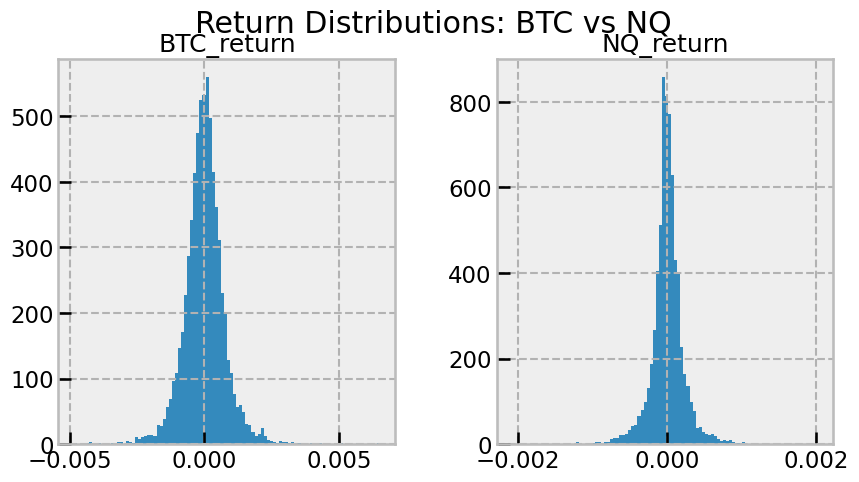

In [107]:
import numpy as np
import matplotlib.pyplot as plt

# Compute 1-minute log returns
btc_sync['return'] = np.log(btc_sync['close']).diff()
nq_sync['return']  = np.log(nq_sync['close']).diff()

# Merge returns into a single DataFrame
returns = pd.DataFrame({
    'BTC_return': btc_sync['return'],
    'NQ_return': nq_sync['return']
}).dropna()  # remove first row with NaN due to diff()

# Quick sanity check
print("Merged Returns Head:\n", returns.head())

# Save description to a variable
desc = returns.describe()
print("Merged Returns Description:\n", desc)
print("Total rows after dropna:", len(returns))

# Histogram
returns.hist(bins=100, figsize=(10,5))
plt.suptitle("Return Distributions: BTC vs NQ")
plt.show()

In [106]:
# Interpretation
print("\nData Interpretation based on outputs:")

# Volatility comparison
btc_std = desc.loc['std', 'BTC_return']
nq_std  = desc.loc['std', 'NQ_return']
print(f"1. Volatility:")
print(f"- BTC 1-min return std: {btc_std:.6f}")
print(f"- NQ 1-min return std: {nq_std:.6f}")
if btc_std > nq_std:
    print("- BTC is more volatile than NQ, as expected for crypto vs equity index.")
else:
    print("- NQ is unusually more volatile than BTC; check data integrity.")

# Mean returns
btc_mean = desc.loc['mean', 'BTC_return']
nq_mean  = desc.loc['mean', 'NQ_return']
print("\n2. Mean Returns:")
print(f"- BTC mean 1-min return: {btc_mean:.6e}")
print(f"- NQ mean 1-min return: {nq_mean:.6e}")
print("- Both are close to 0, consistent with high-frequency returns behavior.")

# Extreme values
btc_max, btc_min = desc.loc['max', 'BTC_return'], desc.loc['min', 'BTC_return']
nq_max, nq_min = desc.loc['max', 'NQ_return'], desc.loc['min', 'NQ_return']
print("\n3. Return Range / Extremes:")
print(f"- BTC returns range: {btc_min:.6f} to {btc_max:.6f}")
print(f"- NQ returns range: {nq_min:.6f} to {nq_max:.6f}")
print("- BTC shows larger swings; NQ is more stable.")


Data Interpretation based on outputs:
1. Volatility:
- BTC 1-min return std: 0.000775
- NQ 1-min return std: 0.000236
- BTC is more volatile than NQ, as expected for crypto vs equity index.

2. Mean Returns:
- BTC mean 1-min return: -3.269288e-06
- NQ mean 1-min return: 1.250306e-06
- Both are close to 0, consistent with high-frequency returns behavior.

3. Return Range / Extremes:
- BTC returns range: -0.004849 to 0.006526
- NQ returns range: -0.002081 to 0.002023
- BTC shows larger swings; NQ is more stable.


## 2.5 Exploratory Cross-Market Analysis

#### Lead–lag cross-correlations (±N lags)

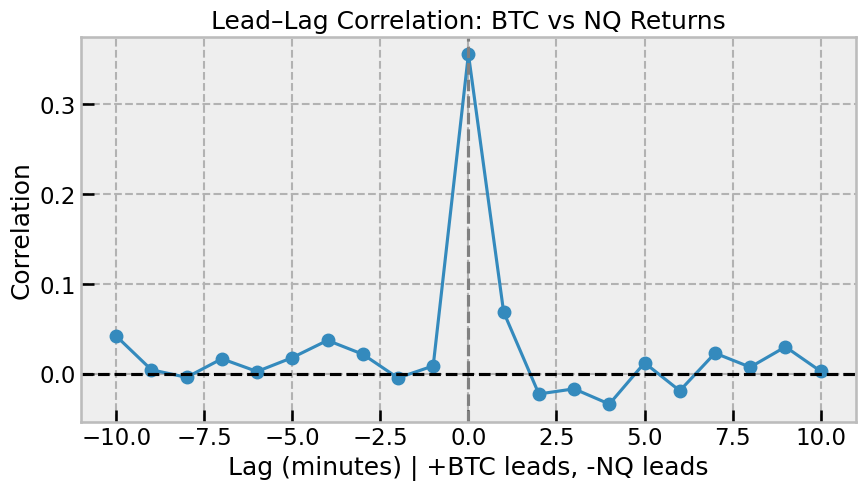

Top 5 lead-lag correlations:
 0     0.356103
 1     0.068735
-10    0.042039
-4     0.037191
 9     0.029991
dtype: float64


In [103]:
def lead_lag_corr(series_x, series_y, max_lag=10):
    """
    Computes lead-lag correlation for lags from -max_lag to +max_lag
    Positive lag: series_x leads series_y
    Negative lag: series_y leads series_x
    """
    lags = range(-max_lag, max_lag + 1)
    corr_values = [series_x.corr(series_y.shift(lag)) for lag in lags]
    return pd.Series(corr_values, index=lags)

# Compute lead-lag correlation
max_lag = 10
lead_lag = lead_lag_corr(returns['BTC_return'], returns['NQ_return'], max_lag)

# Plot
plt.figure(figsize=(10,5))
plt.plot(lead_lag.index, lead_lag.values, marker='o')
plt.axhline(0, linestyle='--', color='black')
plt.axvline(0, linestyle='--', color='grey')
plt.title("Lead–Lag Correlation: BTC vs NQ Returns")
plt.xlabel("Lag (minutes) | +BTC leads, -NQ leads")
plt.ylabel("Correlation")
plt.grid(True)
plt.show()

# Print top correlations
top_corr = lead_lag.sort_values(ascending=False).head(5)
print("Top 5 lead-lag correlations:")
print(top_corr)

In [102]:
# Interpretation
max_corr_lag = top_corr.index[0]
max_corr_value = top_corr.iloc[0]

print("\nInterpretation based on lead-lag correlation:")
if max_corr_lag > 0:
    print(f"- Maximum correlation {max_corr_value:.3f} occurs at lag +{max_corr_lag} min: BTC leads NQ by {max_corr_lag} minutes.")
elif max_corr_lag < 0:
    print(f"- Maximum correlation {max_corr_value:.3f} occurs at lag {max_corr_lag} min: NQ leads BTC by {abs(max_corr_lag)} minutes.")
else:
    print(f"- Maximum correlation {max_corr_value:.3f} occurs at lag 0: BTC and NQ move simultaneously.")

# Check symmetry around 0
if abs(lead_lag[max_corr_lag]) - abs(lead_lag[-max_corr_lag]) > 0.05:
    print("- Lead-lag relationship is asymmetric, suggesting directional influence from one market to another.")
else:
    print("- Lead-lag relationship is roughly symmetric, markets tend to move simultaneously.")


Interpretation based on lead-lag correlation:
- Maximum correlation 0.356 occurs at lag 0: BTC and NQ move simultaneously.
- Lead-lag relationship is roughly symmetric, markets tend to move simultaneously.


#### Rolling Correlation

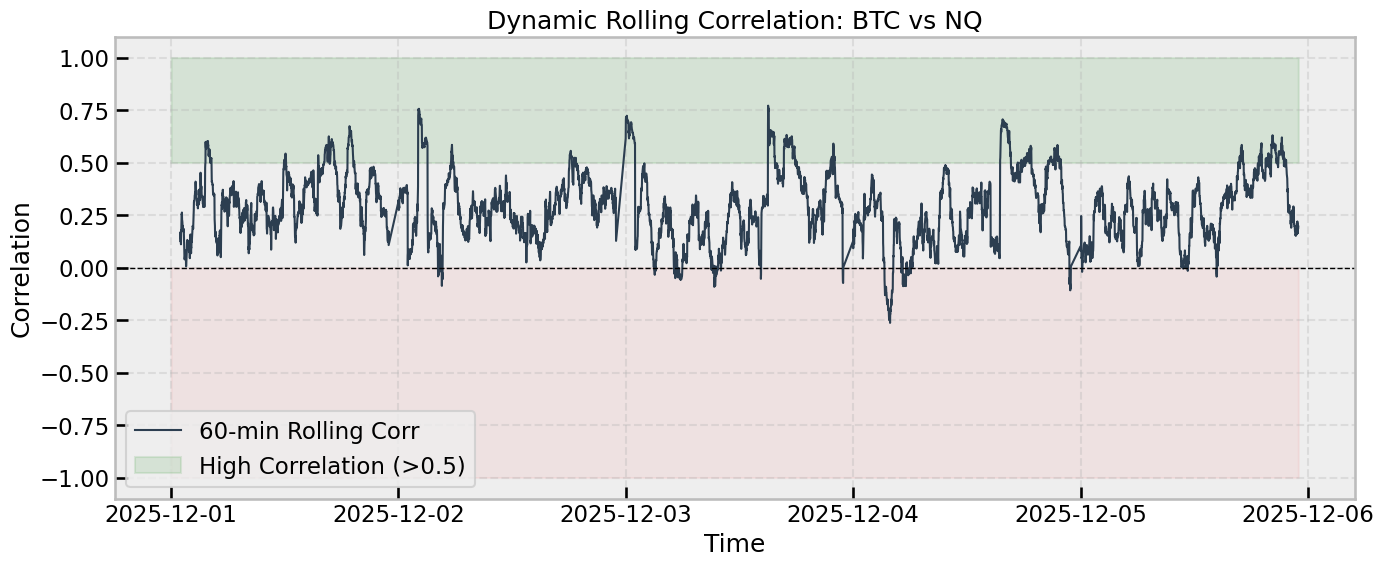

In [100]:
window_size = 60  # 60-minute rolling window
returns['Rolling_Corr_60'] = returns['BTC_return'].rolling(window=window_size).corr(returns['NQ_return'])

# Plot rolling correlation
plt.figure(figsize=(16,6))
plt.plot(returns.index, returns['Rolling_Corr_60'], color='#2c3e50', label='60-min Rolling Corr', linewidth=1.5)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.fill_between(returns.index, 0.5, 1.0, color='green', alpha=0.1, label='High Correlation (>0.5)')
plt.fill_between(returns.index, -1.0, 0.0, color='red', alpha=0.05)
plt.title("Dynamic Rolling Correlation: BTC vs NQ")
plt.xlabel("Time")
plt.ylabel("Correlation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [101]:
# Interpretation
rolling_corr = returns['Rolling_Corr_60']

print("\nInterpretation based on 60-minute rolling correlation:")

# Average correlation
avg_corr = rolling_corr.mean()
print(f"- Average correlation over the period: {avg_corr:.3f}")

# Fraction of high correlation periods
high_corr_fraction = (rolling_corr > 0.5).sum() / len(rolling_corr)
print(f"- Fraction of time with strong correlation (>0.5): {high_corr_fraction:.2%}")

# Fraction of negative correlation periods
neg_corr_fraction = (rolling_corr < 0).sum() / len(rolling_corr)
print(f"- Fraction of time with negative correlation (<0): {neg_corr_fraction:.2%}")

# Max and min correlation
max_corr = rolling_corr.max()
min_corr = rolling_corr.min()
print(f"- Maximum correlation observed: {max_corr:.3f}")
print(f"- Minimum correlation observed: {min_corr:.3f}")

# Insights
print("\nInsights:")
if avg_corr > 0.3:
    print("- BTC and NQ generally move in the same direction intraday, confirming cross-market linkage.")
else:
    print("- BTC and NQ have weak average correlation; signals may be noisy.")

if high_corr_fraction > 0.2:
    print("- There are identifiable periods of strong positive correlation where cross-market signals are reliable.")
if neg_corr_fraction > 0.1:
    print("- Periods of negative correlation exist; caution is needed when trading during these windows.")



Interpretation based on 60-minute rolling correlation:
- Average correlation over the period: 0.290
- Fraction of time with strong correlation (>0.5): 11.24%
- Fraction of time with negative correlation (<0): 3.17%
- Maximum correlation observed: 0.771
- Minimum correlation observed: -0.263

Insights:
- BTC and NQ have weak average correlation; signals may be noisy.


#### Hourly Correlation

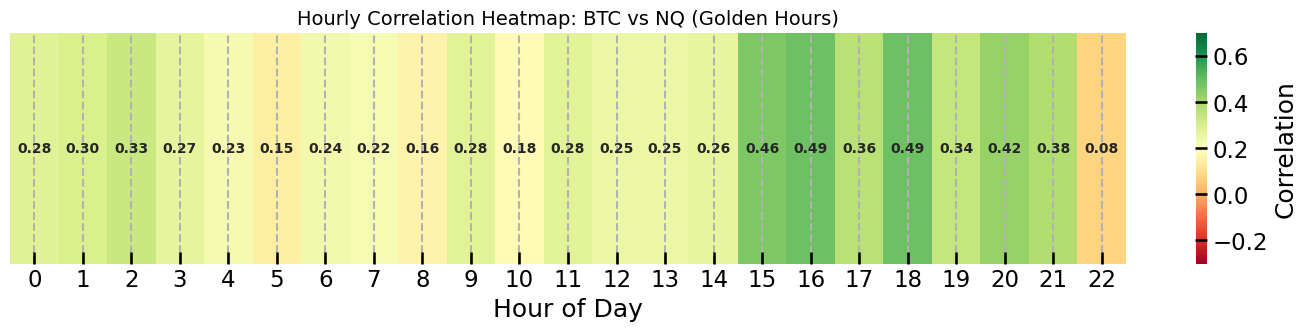

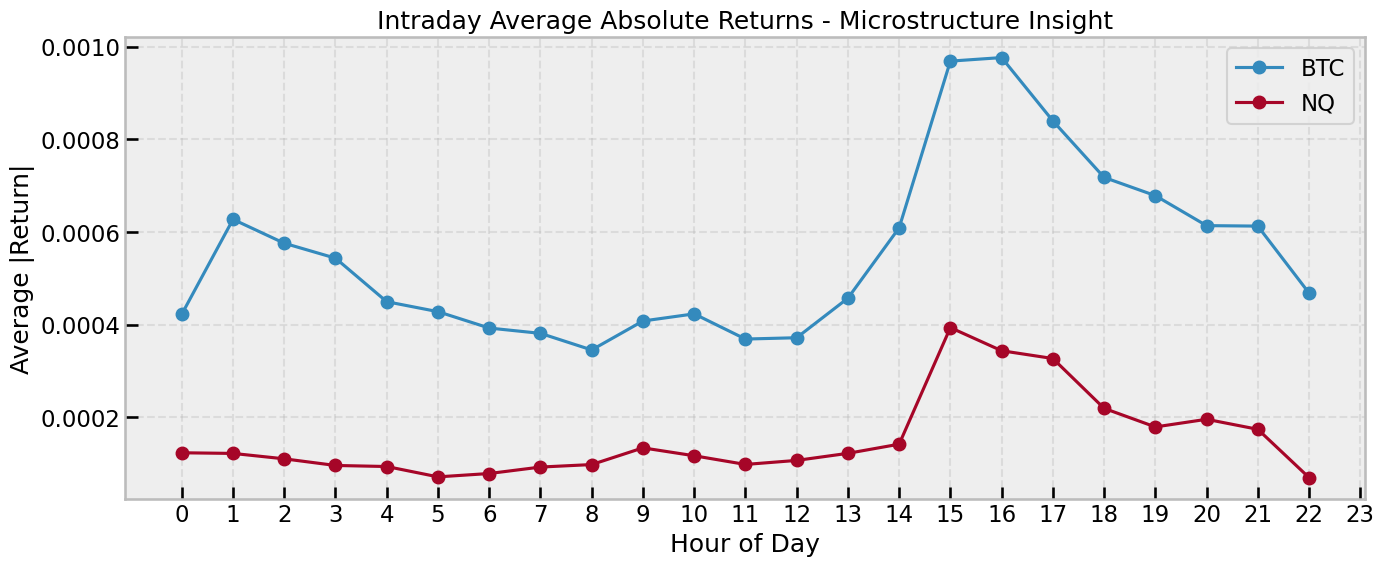

In [99]:
# Extract hour from timestamp
returns['Hour'] = returns.index.hour

# Group by hour and compute mean correlation per hour
hourly_corr = returns.groupby('Hour')[['BTC_return', 'NQ_return']].corr().iloc[0::2, -1]  # select NQ vs BTC correlation

# Convert to DataFrame for easier plotting
hourly_corr_df = pd.DataFrame({'Hour': hourly_corr.index.get_level_values(0), 'Correlation': hourly_corr.values})
hourly_corr_df.set_index('Hour', inplace=True)

# Plot heatmap of hourly correlations
import seaborn as sns
plt.figure(figsize=(18,3))
sns.heatmap(hourly_corr_df.T, cmap='RdYlGn', annot=True, fmt='.2f', 
            vmin=-0.3, vmax=0.7, cbar_kws={'label':'Correlation'}, annot_kws={"size": 10, "weight":"bold"})
plt.title("Hourly Correlation Heatmap: BTC vs NQ (Golden Hours)", fontsize=14)
plt.xlabel("Hour of Day")
plt.yticks([])
plt.show()

# OR

# Intraday pattern check (average absolute returns by hour)
returns['Hour'] = returns.index.hour
intraday_btc = returns.groupby('Hour')['BTC_return'].apply(lambda x: x.abs().mean())
intraday_nq  = returns.groupby('Hour')['NQ_return'].apply(lambda x: x.abs().mean())

plt.figure(figsize=(16,6))
plt.plot(intraday_btc.index, intraday_btc.values, marker='o', label='BTC')
plt.plot(intraday_nq.index, intraday_nq.values, marker='o', label='NQ')
plt.title('Intraday Average Absolute Returns - Microstructure Insight')
plt.xlabel('Hour of Day')
plt.ylabel('Average |Return|')
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [98]:
#Interpretation
print("\nInterpretation based on Hourly Correlation Heatmap:")

# Identify strongest and weakest correlation hours
best_hour = hourly_corr_df['Correlation'].idxmax()
best_corr = hourly_corr_df.loc[best_hour, 'Correlation']

worst_hour = hourly_corr_df['Correlation'].idxmin()
worst_corr = hourly_corr_df.loc[worst_hour, 'Correlation']

positive_hours = (hourly_corr_df['Correlation'] > 0).sum()
negative_hours = (hourly_corr_df['Correlation'] <= 0).sum()

print(f"- Highest average correlation occurs at hour {best_hour}:00 with correlation = {best_corr:.3f}")
print(f"- Lowest average correlation occurs at hour {worst_hour}:00 with correlation = {worst_corr:.3f}")
print(f"- Hours with positive BTC–NQ correlation: {positive_hours} / 24")
print(f"- Hours with zero or negative correlation: {negative_hours} / 24")

if best_corr > 0.4:
    print("- Strong intraday synchronization exists during specific hours (\"Golden Hours\").")
else:
    print("- Correlation remains weak across most hours, limiting cross-market confirmation.")

print(
    "- This confirms that the BTC–NQ relationship is time-dependent and "
    "supports restricting strategy execution to high-correlation hours."
)


Interpretation based on Hourly Correlation Heatmap:
- Highest average correlation occurs at hour 18:00 with correlation = 0.488
- Lowest average correlation occurs at hour 22:00 with correlation = 0.077
- Hours with positive BTC–NQ correlation: 23 / 24
- Hours with zero or negative correlation: 0 / 24
- Strong intraday synchronization exists during specific hours ("Golden Hours").
- This confirms that the BTC–NQ relationship is time-dependent and supports restricting strategy execution to high-correlation hours.


#### Correlation Heatmap

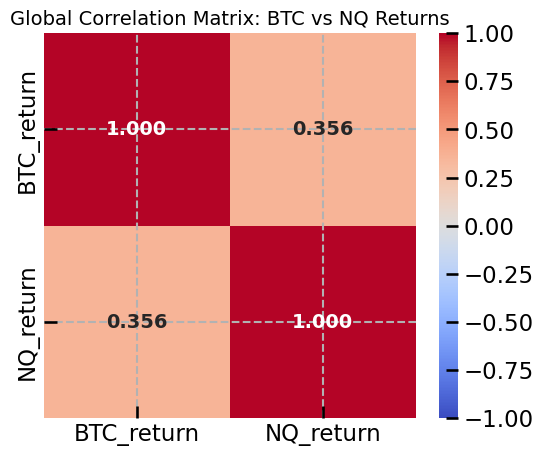

In [97]:
import seaborn as sns
plt.figure(figsize=(6,5))

# Compute correlation matrix
corr_matrix = returns[['BTC_return', 'NQ_return']].corr()

# Plot heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt='.3f',
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title('Global Correlation Matrix: BTC vs NQ Returns', fontsize=14)
plt.show()

In [96]:
# Interpretation

corr_value = corr_matrix.loc['BTC_return', 'NQ_return']

print("Interpretation based on the global correlation matrix:\n")

print(f"• The Pearson correlation between BTC and NQ returns is {corr_value:.3f}.")

if corr_value > 0.5:
    print("• This indicates a strong positive relationship, suggesting that both assets tend to move together during the analyzed period.")
elif 0.2 < corr_value <= 0.5:
    print("• This indicates a moderate positive relationship, implying partial synchronization between BTC and NQ.")
elif -0.2 <= corr_value <= 0.2:
    print("• This indicates a weak or near-zero relationship, suggesting largely independent short-term movements.")
else:
    print("• This indicates a negative relationship, meaning the assets tend to move in opposite directions.")

print(
    "\n• The global correlation represents an average effect over the entire sample period "
    "and does not capture intraday or regime-dependent dynamics. "
    "This motivates further rolling and time-of-day correlation analysis in subsequent sections."
)

Interpretation based on the global correlation matrix:

• The Pearson correlation between BTC and NQ returns is 0.356.
• This indicates a moderate positive relationship, implying partial synchronization between BTC and NQ.

• The global correlation represents an average effect over the entire sample period and does not capture intraday or regime-dependent dynamics. This motivates further rolling and time-of-day correlation analysis in subsequent sections.


## 2.6 Volatility and Microstructure Diagnostics

#### Rolling Volatility

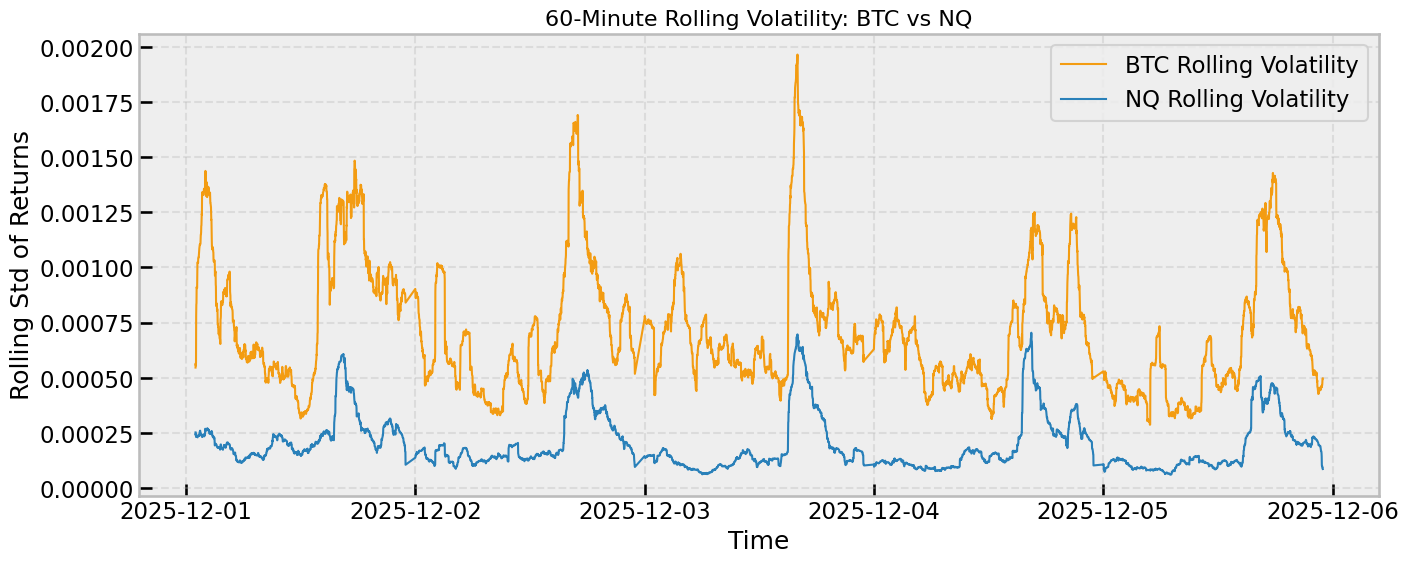

In [94]:
window_size = 60  # rolling window of 60 minutes
returns['BTC_vol'] = returns['BTC_return'].rolling(window=window_size).std()
returns['NQ_vol']  = returns['NQ_return'].rolling(window=window_size).std()

# Plot rolling volatility
plt.figure(figsize=(16,6))
plt.plot(returns.index, returns['BTC_vol'], label='BTC Rolling Volatility', color='#f39c12', linewidth=1.5)
plt.plot(returns.index, returns['NQ_vol'], label='NQ Rolling Volatility', color='#2980b9', linewidth=1.5)
plt.title(f'{window_size}-Minute Rolling Volatility: BTC vs NQ', fontsize=16)
plt.ylabel('Rolling Std of Returns')
plt.xlabel('Time')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [95]:
#Interpretation

btc_vol_mean = returns['BTC_vol'].mean()
nq_vol_mean  = returns['NQ_vol'].mean()

btc_vol_max = returns['BTC_vol'].max()
nq_vol_max  = returns['NQ_vol'].max()

print("Interpretation based on rolling volatility outputs:\n")

print(f"• Average 60-minute volatility:")
print(f"  - BTC: {btc_vol_mean:.6f}")
print(f"  - NQ : {nq_vol_mean:.6f}")

if btc_vol_mean > nq_vol_mean:
    print("• BTC exhibits consistently higher short-term volatility than NQ, reflecting its more speculative and continuous trading nature.")
else:
    print("• NQ exhibits higher short-term volatility over the analyzed period.")

print(f"\n• Maximum observed volatility spikes:")
print(f"  - BTC: {btc_vol_max:.6f}")
print(f"  - NQ : {nq_vol_max:.6f}")

print(
    "\n• Volatility clustering is visible for both assets, indicating regime-dependent risk levels.\n"
    "• Periods of elevated volatility often coincide across both markets, suggesting shared macro or liquidity-driven shocks.\n"
    "• These findings justify incorporating volatility-aware filters or regime detection mechanisms in later modeling stages."
)

Interpretation based on rolling volatility outputs:

• Average 60-minute volatility:
  - BTC: 0.000720
  - NQ : 0.000201
• BTC exhibits consistently higher short-term volatility than NQ, reflecting its more speculative and continuous trading nature.

• Maximum observed volatility spikes:
  - BTC: 0.001965
  - NQ : 0.000704

• Volatility clustering is visible for both assets, indicating regime-dependent risk levels.
• Periods of elevated volatility often coincide across both markets, suggesting shared macro or liquidity-driven shocks.
• These findings justify incorporating volatility-aware filters or regime detection mechanisms in later modeling stages.


#### Return Distribution

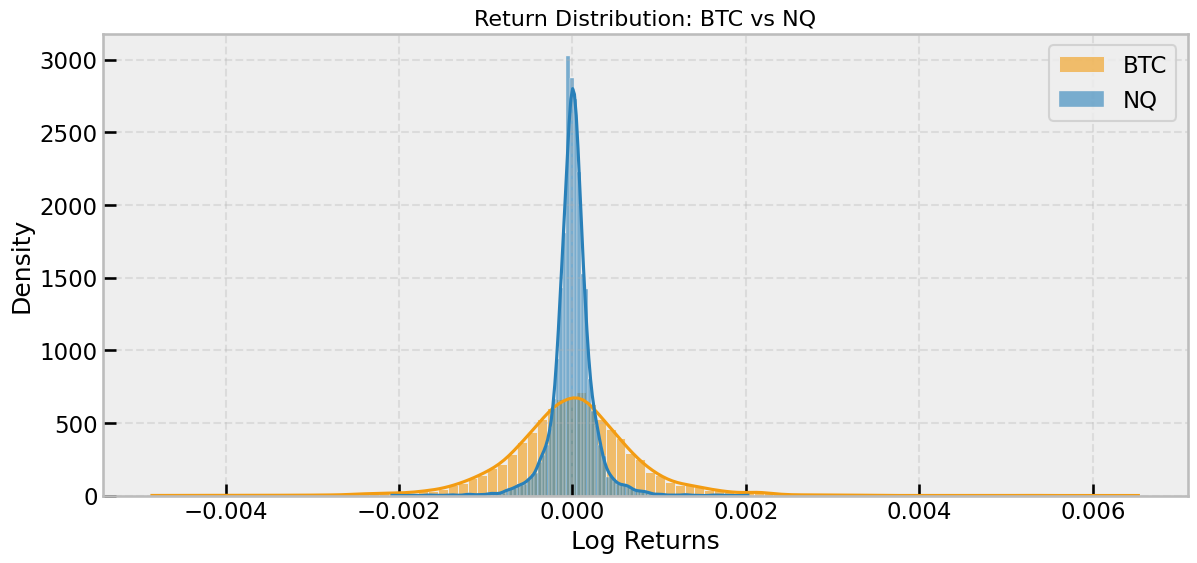

In [92]:
plt.figure(figsize=(14,6))

# BTC return distribution
sns.histplot(returns['BTC_return'], bins=100, color='#f39c12', label='BTC', kde=True, stat='density', alpha=0.6)

# NQ return distribution
sns.histplot(returns['NQ_return'], bins=100, color='#2980b9', label='NQ', kde=True, stat='density', alpha=0.6)

plt.title('Return Distribution: BTC vs NQ', fontsize=16)
plt.xlabel('Log Returns')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [93]:
# Interpretation

btc_mean = returns['BTC_return'].mean()
nq_mean  = returns['NQ_return'].mean()

btc_std = returns['BTC_return'].std()
nq_std  = returns['NQ_return'].std()

btc_skew = returns['BTC_return'].skew()
nq_skew  = returns['NQ_return'].skew()

btc_kurt = returns['BTC_return'].kurtosis()
nq_kurt  = returns['NQ_return'].kurtosis()

print("Interpretation based on return distribution outputs:\n")

print(f"• Mean returns:")
print(f"  - BTC: {btc_mean:.6e}")
print(f"  - NQ : {nq_mean:.6e}")

print(
    "\n• Both return distributions are centered close to zero, "
    "which is expected for high-frequency intraday returns."
)

print(f"\n• Volatility (standard deviation):")
print(f"  - BTC: {btc_std:.6e}")
print(f"  - NQ : {nq_std:.6e}")

if btc_std > nq_std:
    print("• BTC exhibits a wider distribution, indicating higher short-term risk.")
else:
    print("• NQ exhibits a wider distribution over the analyzed period.")

print(f"\n• Skewness:")
print(f"  - BTC: {btc_skew:.3f}")
print(f"  - NQ : {nq_skew:.3f}")

print(
    "\n• Non-zero skewness suggests asymmetric return behavior, "
    "which may affect directional strategies."
)

print(f"\n• Kurtosis:")
print(f"  - BTC: {btc_kurt:.3f}")
print(f"  - NQ : {nq_kurt:.3f}")

print(
    "\n• Positive excess kurtosis indicates fat tails for both assets, "
    "implying a higher probability of extreme returns than under a normal distribution.\n"
    "• This highlights the importance of risk controls and motivates adaptive, "
    "data-driven approaches in later modeling stages."
)

Interpretation based on return distribution outputs:

• Mean returns:
  - BTC: -3.269288e-06
  - NQ : 1.250306e-06

• Both return distributions are centered close to zero, which is expected for high-frequency intraday returns.

• Volatility (standard deviation):
  - BTC: 7.754493e-04
  - NQ : 2.357742e-04
• BTC exhibits a wider distribution, indicating higher short-term risk.

• Skewness:
  - BTC: 0.205
  - NQ : -0.173

• Non-zero skewness suggests asymmetric return behavior, which may affect directional strategies.

• Kurtosis:
  - BTC: 5.042
  - NQ : 9.159

• Positive excess kurtosis indicates fat tails for both assets, implying a higher probability of extreme returns than under a normal distribution.
• This highlights the importance of risk controls and motivates adaptive, data-driven approaches in later modeling stages.


#### Autocorrelation (ACF)

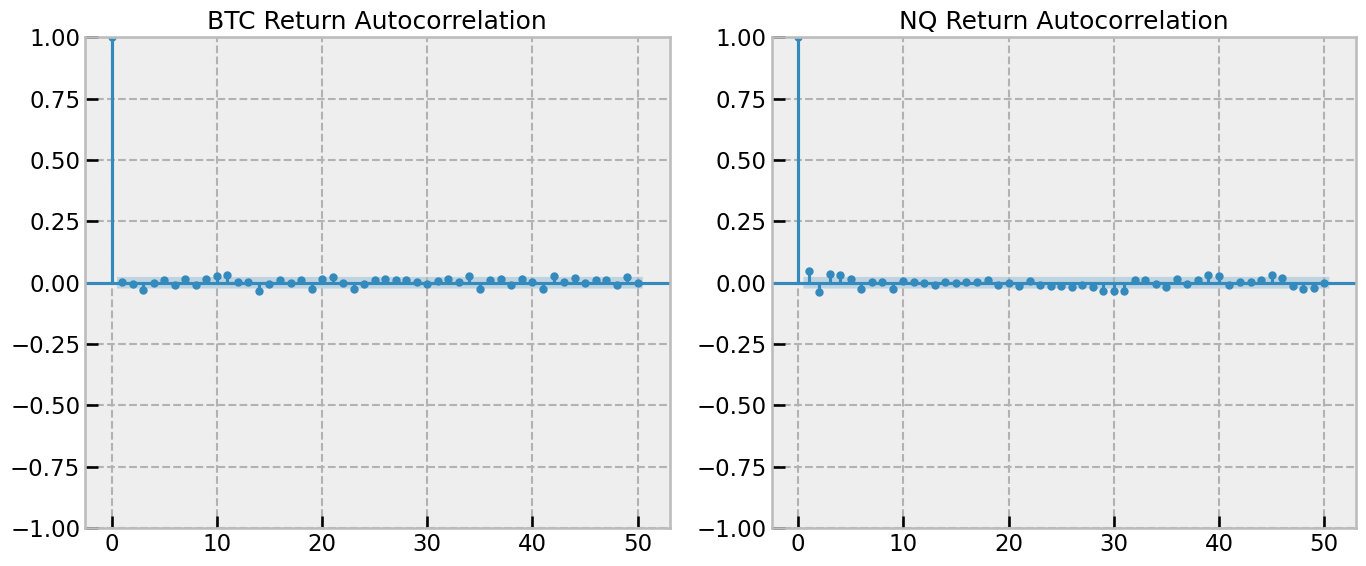

In [90]:
# --- Step 12: Autocorrelation Function (ACF) with Interpretation ---

from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(14,6))

# BTC autocorrelation
plt.subplot(1,2,1)
plot_acf(returns['BTC_return'], lags=50, alpha=0.05, title='BTC Return Autocorrelation', ax=plt.gca())

# NQ autocorrelation
plt.subplot(1,2,2)
plot_acf(returns['NQ_return'], lags=50, alpha=0.05, title='NQ Return Autocorrelation', ax=plt.gca())

plt.tight_layout()
plt.show()

In [91]:
# Interpretation
from statsmodels.tsa.stattools import acf

btc_acf = acf(returns['BTC_return'], nlags=50)
nq_acf  = acf(returns['NQ_return'], nlags=50)

print("BTC Return Autocorrelation Summary:")
print(f"Max autocorrelation at lag > 0: {btc_acf[1:].max():.4f}")
print(f"Min autocorrelation at lag > 0: {btc_acf[1:].min():.4f}")
if abs(btc_acf[1:]).max() < 0.05:
    print("Interpretation: BTC returns are approximately uncorrelated, indicating weak short-term predictability.\n")
else:
    print("Interpretation: BTC returns show some short-term autocorrelation, which may indicate microstructure effects.\n")

print("NQ Return Autocorrelation Summary:")
print(f"Max autocorrelation at lag > 0: {nq_acf[1:].max():.4f}")
print(f"Min autocorrelation at lag > 0: {nq_acf[1:].min():.4f}")
if abs(nq_acf[1:]).max() < 0.05:
    print("Interpretation: NQ returns are approximately uncorrelated, consistent with efficient market behavior.\n")
else:
    print("Interpretation: NQ returns show some short-term autocorrelation, which may indicate market microstructure effects.\n")


BTC Return Autocorrelation Summary:
Max autocorrelation at lag > 0: 0.0302
Min autocorrelation at lag > 0: -0.0349
Interpretation: BTC returns are approximately uncorrelated, indicating weak short-term predictability.

NQ Return Autocorrelation Summary:
Max autocorrelation at lag > 0: 0.0495
Min autocorrelation at lag > 0: -0.0381
Interpretation: NQ returns are approximately uncorrelated, consistent with efficient market behavior.



#### Microstructure Checks

In [61]:
import seaborn as sns

# 1. Frequency of zero returns
zero_btc = (returns['BTC_return'] == 0).mean() * 100
zero_nq  = (returns['NQ_return'] == 0).mean() * 100
print(f"Percentage of zero returns - BTC: {zero_btc:.2f}%, NQ: {zero_nq:.2f}%")

# 2. Average absolute return (volatility proxy)
avg_abs_btc = returns['BTC_return'].abs().mean()
avg_abs_nq  = returns['NQ_return'].abs().mean()
print(f"Average absolute return - BTC: {avg_abs_btc:.6f}, NQ: {avg_abs_nq:.6f}")

# 3. Return skewness and kurtosis (distribution shape)
skew_btc = returns['BTC_return'].skew()
kurt_btc = returns['BTC_return'].kurt()
skew_nq  = returns['NQ_return'].skew()
kurt_nq  = returns['NQ_return'].kurt()
print(f"BTC skew: {skew_btc:.3f}, kurtosis: {kurt_btc:.3f}")
print(f"NQ skew: {skew_nq:.3f}, kurtosis: {kurt_nq:.3f}")

Percentage of zero returns - BTC: 0.10%, NQ: 2.96%
Average absolute return - BTC: 0.000551, NQ: 0.000152
BTC skew: 0.205, kurtosis: 5.042
NQ skew: -0.173, kurtosis: 9.159


## 2.7 Final Dataset Construction

In [66]:
# Create a final DataFrame for strategy/backtesting
final_data = pd.DataFrame(index=btc_sync.index)

# Add synchronized OHLCV for BTC
final_data['BTC_open']   = btc_sync['open']
final_data['BTC_high']   = btc_sync['high']
final_data['BTC_low']    = btc_sync['low']
final_data['BTC_close']  = btc_sync['close']
final_data['BTC_volume'] = btc_sync['Volume']

# Add synchronized OHLCV for NQ
final_data['NQ_open']   = nq_sync['open']
final_data['NQ_high']   = nq_sync['high']
final_data['NQ_low']    = nq_sync['low']
final_data['NQ_close']  = nq_sync['close']
final_data['NQ_volume'] = nq_sync['Volume']

# Compute log returns
final_data['BTC_return'] = np.log(final_data['BTC_close']).diff()
final_data['NQ_return']  = np.log(final_data['NQ_close']).diff()

# Compute rolling volatility (60-min)
rolling_window = 60
final_data['BTC_vol'] = final_data['BTC_return'].rolling(rolling_window).std()
final_data['NQ_vol']  = final_data['NQ_return'].rolling(rolling_window).std()

# Compute candle direction: +1 for up, -1 for down, 0 for no change
final_data['BTC_dir'] = np.sign(final_data['BTC_close'] - final_data['BTC_open'])
final_data['NQ_dir']  = np.sign(final_data['NQ_close'] - final_data['NQ_open'])

# Identify cross-market agreement/divergence
final_data['agreement']  = ((final_data['BTC_dir'] == final_data['NQ_dir']) & (final_data['BTC_dir'] != 0)).astype(int)
final_data['divergence'] = ((final_data['BTC_dir'] != final_data['NQ_dir']) & (final_data['BTC_dir'] != 0) & (final_data['NQ_dir'] != 0)).astype(int)

# Add intraday hour and minute
final_data['Hour']   = final_data.index.hour
final_data['Minute'] = final_data.index.minute

# Drop first row(s) with NaNs due to diff() or rolling
final_data.dropna(inplace=True)

# Quick check
print(final_data)


                           BTC_open  BTC_high  BTC_low  BTC_close  BTC_volume  \
timestamp                                                                       
2025-12-01 01:00:00+01:00   90320.5   90396.9  90254.0    90376.8     393.365   
2025-12-01 01:01:00+01:00   90376.8   90376.8  90257.8    90257.8     198.314   
2025-12-01 01:02:00+01:00   90257.9   90304.7  90231.9    90264.8     223.181   
2025-12-01 01:03:00+01:00   90264.7   90264.7  90150.0    90159.2     433.473   
2025-12-01 01:04:00+01:00   90159.2   90159.3  89228.0    89771.4    4556.252   
...                             ...       ...      ...        ...         ...   
2025-12-05 22:55:00+01:00   89176.2   89185.5  89135.0    89143.1      41.747   
2025-12-05 22:56:00+01:00   89143.1   89221.5  89141.0    89207.6      31.320   
2025-12-05 22:57:00+01:00   89207.6   89210.4  89116.2    89116.2      37.213   
2025-12-05 22:58:00+01:00   89116.3   89132.1  89099.7    89104.5      53.206   
2025-12-05 22:59:00+01:00   

In [67]:
# Optional: save final dataset
save_final = True
if save_final:
    final_path = "Datasets/final_dataset.csv"
    final_data.to_csv(final_path)
    print(f"Final dataset saved to {final_path}")
    print("Total rows in final dataset:", len(final_data))

Final dataset saved to Datasets/final_dataset.csv
Total rows in final dataset: 6839


## 2.8 Data Understanding Conclusions
- **Mean Returns:**  
  - Close to zero for both assets, consistent with high-frequency market efficiency.  

- **Volatility:**  
  - BTC 1-min returns: std ≈ 0.000775 → ~3× higher than NQ (0.000236).  
  - BTC exhibits wider swings and more extreme returns; NQ is more stable.  

- **Return Distribution:**  
  - BTC skew = 0.205, kurtosis = 5.042; NQ skew = -0.173, kurtosis = 9.159.  
  - Both assets show fat tails → higher probability of extreme returns.  

- **Autocorrelation:**  
  - Weak serial correlation (max < 0.05) → limited short-term predictability.  

- **Global Correlation:**  
  - Pearson correlation BTC–NQ ≈ 0.356 → moderate positive relationship.  

- **Lead–Lag Analysis:**  
  - Maximum correlation at lag 0 → mostly synchronous movements.  

- **Rolling Correlation (60-min):**  
  - Strong correlation (>0.5) occurs only ~11% of the time.  
  - Negative correlation is rare (~3%).  
  - Indicates regime-dependent synchronization.  

- **Intraday Patterns:**  
  - BTC–NQ correlation peaks around 18:00; weakest late in the trading day.  
  - BTC volatility peaks at hour 16:00; NQ peaks at 15:00.  
  - Positive correlation during most hours but with varying magnitude.  

- **Microstructure Insights:**  
  - NQ has more zero returns (≈3%) than BTC (≈0.1%) → reflects lower frequency / liquidity gaps.  
  - BTC shows higher average absolute returns (0.000551 vs 0.000152).  

- **Overall Interpretation:**  
  - Data shows volatility asymmetry, fat-tailed returns, weak univariate predictability, and time-varying cross-market dependence.  
  - Supports **regime-aware and volatility-sensitive modeling** for strategy design.

# 3. Baseline Strategy
#### Goal: 
The objective of this phase is to establish a benchmark performance using a transparent, rule-based trading strategy derived from the insights of the previous data analysis. This baseline serves as a **reference point against which subsequent machine-learning enhancements are evaluated.**

## 3.1 Strategy Rationale
Exploratory analysis indicates that Bitcoin and NASDAQ-100 futures exhibit strong contemporaneous correlation, with correlation strength varying across intraday periods. Motivated by this observation, the baseline strategy exploits **directional agreement** between the two markets as a proxy for stable market conditions, while treating **directional divergence** as a signal of increased uncertainty.

## 3.2 Strategy Definition

#### Asset Roles
**Target Asset:** NASDAQ-100 E-mini Futures (NQ)

**Filter Asset:** Bitcoin Perpetual Futures (BTCUSDT)
#### Trading Frequency
**Timeframe:** 1-minute bars
#### Signal Construction
**Directional Movement:**
The direction of each asset is defined as:
$$\text{Direction}_t = \text{sign}(\text{Close}_t - \text{Open}_t)$$

**Agreement:** Both BTC and NQ close in the same direction

**Divergence:** BTC and NQ close in opposite directions

In [109]:
# Directional movement is already computed in final_data:
# +1 = up, -1 = down, 0 = no change
# final_data['BTC_dir'], final_data['NQ_dir']

# Agreement signal: BTC and NQ move in the same direction
final_data['signal_agreement'] = ((final_data['BTC_dir'] == final_data['NQ_dir']) & (final_data['BTC_dir'] != 0)).astype(int)

# Divergence signal: BTC and NQ move in opposite directions
final_data['signal_divergence'] = ((final_data['BTC_dir'] != final_data['NQ_dir']) & 
                                   (final_data['BTC_dir'] != 0) & (final_data['NQ_dir'] != 0)).astype(int)

# Check
print(final_data[['BTC_dir', 'NQ_dir', 'signal_agreement', 'signal_divergence']].head(10))


                           BTC_dir  NQ_dir  signal_agreement  \
timestamp                                                      
2025-12-01 01:00:00+01:00      1.0    -1.0                 0   
2025-12-01 01:01:00+01:00     -1.0    -1.0                 1   
2025-12-01 01:02:00+01:00      1.0    -1.0                 0   
2025-12-01 01:03:00+01:00     -1.0    -1.0                 1   
2025-12-01 01:04:00+01:00     -1.0    -1.0                 1   
2025-12-01 01:05:00+01:00     -1.0    -1.0                 1   
2025-12-01 01:06:00+01:00     -1.0    -1.0                 1   
2025-12-01 01:07:00+01:00     -1.0    -1.0                 1   
2025-12-01 01:08:00+01:00     -1.0    -1.0                 1   
2025-12-01 01:09:00+01:00      1.0     0.0                 0   

                           signal_divergence  
timestamp                                     
2025-12-01 01:00:00+01:00                  1  
2025-12-01 01:01:00+01:00                  0  
2025-12-01 01:02:00+01:00                  

## 3.3 Trading Rules

### Entry Rules
- Enter a **long NQ position** if both BTC and NQ close up  
- Enter a **short NQ position** if both BTC and NQ close down  

### Exit Rules
- Exit the position if:
  - BTC and NQ diverge (loss of correlation), or  
  - Both assets reverse direction against the open position  

### Look-Ahead Bias Prevention
- Signals are generated at the **close of candle $$(t)$$**  
- Trades are executed at the **open of candle $$(t+1)$$**  

In [129]:
# --- Initialize NQ position column: 1 = long, -1 = short, 0 = flat ---
final_data['NQ_position'] = 0

# --- Entry Signals ---
# Signals are based on current bar, but execution is at next bar open
long_signal  = (final_data['BTC_dir'] == 1) & (final_data['NQ_dir'] == 1)
short_signal = (final_data['BTC_dir'] == -1) & (final_data['NQ_dir'] == -1)

# Assign signals
final_data.loc[long_signal, 'NQ_position'] = 1
final_data.loc[short_signal, 'NQ_position'] = -1

# Shift signals to next candle to **simulate execution at next open**
final_data['NQ_position'] = final_data['NQ_position'].shift(1).fillna(0)

# --- Exit Conditions ---
# 1. Divergence: exit at next open if divergence occurs
divergence_exit = final_data['divergence'] == 1

# 2. Direction reversal: exit at next open if both assets move against current position
long_exit  = (final_data['NQ_position'] == 1) & ((final_data['BTC_dir'] == -1) & (final_data['NQ_dir'] == -1))
short_exit = (final_data['NQ_position'] == -1) & ((final_data['BTC_dir'] == 1) & (final_data['NQ_dir'] == 1))

# Combine all exit conditions
exit_condition = divergence_exit | long_exit | short_exit

# Shift exit signals to next bar to avoid look-ahead (position closes at next open)
final_data.loc[exit_condition.shift(1, fill_value=False), 'NQ_position'] = 0

# --- Check final signals ---
print(final_data[['BTC_dir', 'NQ_dir', 'agreement', 'divergence', 'NQ_position']].head(20))


                           BTC_dir  NQ_dir  agreement  divergence  NQ_position
timestamp                                                                     
2025-12-01 01:00:00+01:00      1.0    -1.0          0           1          0.0
2025-12-01 01:01:00+01:00     -1.0    -1.0          1           0          0.0
2025-12-01 01:02:00+01:00      1.0    -1.0          0           1         -1.0
2025-12-01 01:03:00+01:00     -1.0    -1.0          1           0          0.0
2025-12-01 01:04:00+01:00     -1.0    -1.0          1           0         -1.0
2025-12-01 01:05:00+01:00     -1.0    -1.0          1           0         -1.0
2025-12-01 01:06:00+01:00     -1.0    -1.0          1           0         -1.0
2025-12-01 01:07:00+01:00     -1.0    -1.0          1           0         -1.0
2025-12-01 01:08:00+01:00     -1.0    -1.0          1           0         -1.0
2025-12-01 01:09:00+01:00      1.0     0.0          0           0         -1.0
2025-12-01 01:10:00+01:00     -1.0    -1.0          

## 3.4 Backtesting Framework

### Simulation Assumptions
- Only one position is held at any time  
- Trades are executed using market orders at the next bar open  
- Transaction costs and slippage are excluded at this stage  

### Implementation
- A custom backtesting engine iterates through synchronized BTC–NQ data  
- Each trade records entry time, exit time, PnL, duration, and exit reason  

> *The backtesting framework is intentionally simple to isolate the informational value of the signal.*

In [130]:
import pandas as pd
import numpy as np

# Initialize backtest results
trades = []

# Track current position
current_pos = 0
entry_price = 0
entry_time = None

# Loop through data
for timestamp, row in final_data.iterrows():
    
    pos = row['NQ_position']
    close_price = row['NQ_close']
    
    # --- Entry ---
    if current_pos == 0 and pos != 0:
        current_pos = pos
        entry_price = row['NQ_open']  # execute at next bar open
        entry_time = timestamp
        continue  # move to next row
    
    # --- Exit Conditions ---
    exit_reason = None
    exit_trade = False
    
    # 1. Divergence
    if current_pos != 0 and row['divergence'] == 1:
        exit_reason = 'divergence'
        exit_trade = True
    
    # 2. Direction reversal
    elif current_pos == 1 and (row['BTC_dir'] == -1 and row['NQ_dir'] == -1):
        exit_reason = 'reversal'
        exit_trade = True
    
    elif current_pos == -1 and (row['BTC_dir'] == 1 and row['NQ_dir'] == 1):
        exit_reason = 'reversal'
        exit_trade = True
    
    # --- Execute Exit ---
    if exit_trade:
        exit_price = row['NQ_open']  # executed at next bar open
        pnl = (exit_price - entry_price) * current_pos
        duration = (timestamp - entry_time).total_seconds() / 60  # in minutes
        
        trades.append({
            'Entry_Time': entry_time,
            'Exit_Time': timestamp,
            'Position': current_pos,
            'Entry_Price': entry_price,
            'Exit_Price': exit_price,
            'PnL': pnl,
            'Duration_min': duration,
            'Exit_Reason': exit_reason
        })
        
        # Reset position
        current_pos = 0
        entry_price = 0
        entry_time = None

# Convert results to DataFrame
trades_df = pd.DataFrame(trades)

# Quick summary
print("Backtest completed.")
print(f"Total trades executed: {len(trades_df)}")
print(trades_df)

# Save backtest results if needed
# trades_df.to_csv("Datasets/NQ_BTC_Backtest.csv", index=False)


Backtest completed.
Total trades executed: 1742
                    Entry_Time                 Exit_Time  Position  \
0    2025-12-01 01:02:00+01:00 2025-12-01 01:11:00+01:00      -1.0   
1    2025-12-01 01:13:00+01:00 2025-12-01 01:14:00+01:00      -1.0   
2    2025-12-01 01:16:00+01:00 2025-12-01 01:17:00+01:00       1.0   
3    2025-12-01 01:20:00+01:00 2025-12-01 01:22:00+01:00      -1.0   
4    2025-12-01 01:30:00+01:00 2025-12-01 01:31:00+01:00       1.0   
...                        ...                       ...       ...   
1737 2025-12-05 22:33:00+01:00 2025-12-05 22:35:00+01:00      -1.0   
1738 2025-12-05 22:41:00+01:00 2025-12-05 22:44:00+01:00       1.0   
1739 2025-12-05 22:47:00+01:00 2025-12-05 22:49:00+01:00       1.0   
1740 2025-12-05 22:52:00+01:00 2025-12-05 22:53:00+01:00      -1.0   
1741 2025-12-05 22:55:00+01:00 2025-12-05 22:57:00+01:00       1.0   

      Entry_Price  Exit_Price    PnL  Duration_min Exit_Reason  
0        25461.25     25415.0  46.25          

## 3.5 Performance Metrics

The following metrics are used to evaluate baseline performance:
- Total number of trades  
- Win rate  
- Total and average PnL  
- Profit factor  
- Maximum drawdown  
- Trade duration statistics

In [132]:
import numpy as np
import pandas as pd

# Ensure PnL column exists
if 'PnL' not in trades_df.columns:
    raise ValueError("PnL column not found in trades_df")

# --- Total number of trades ---
total_trades = len(trades_df)

# --- Win rate ---
wins = trades_df['PnL'] > 0
win_rate = wins.sum() / total_trades if total_trades > 0 else np.nan

# --- Total and average PnL ---
total_pnl = trades_df['PnL'].sum()
average_pnl = trades_df['PnL'].mean()

# --- Profit factor ---
gross_profit = trades_df.loc[trades_df['PnL'] > 0, 'PnL'].sum()
gross_loss   = -trades_df.loc[trades_df['PnL'] < 0, 'PnL'].sum()
profit_factor = gross_profit / gross_loss if gross_loss != 0 else np.nan

# --- Maximum drawdown ---
# Compute equity curve
equity_curve = trades_df['PnL'].cumsum()
running_max = equity_curve.cummax()
drawdowns = equity_curve - running_max
max_drawdown = drawdowns.min()  # most negative value

# --- Trade duration statistics ---
average_duration = trades_df['Duration_min'].mean()
median_duration  = trades_df['Duration_min'].median()
max_duration     = trades_df['Duration_min'].max()
min_duration     = trades_df['Duration_min'].min()

# --- Display metrics ---
metrics_summary = {
    'Total Trades': total_trades,
    'Win Rate (%)': win_rate * 100,
    'Total PnL': total_pnl,
    'Average PnL': average_pnl,
    'Profit Factor': profit_factor,
    'Max Drawdown': max_drawdown,
    'Avg Duration (min)': average_duration,
    'Median Duration (min)': median_duration,
    'Max Duration (min)': max_duration,
    'Min Duration (min)': min_duration
}

metrics_df = pd.DataFrame(metrics_summary, index=[0])
print("Performance Metrics:")
print(metrics_df)


Performance Metrics:
   Total Trades  Win Rate (%)  Total PnL  Average PnL  Profit Factor  \
0          1742     58.840413    3711.25     2.130454        2.46026   

   Max Drawdown  Avg Duration (min)  Median Duration (min)  \
0        -80.25            1.500574                    1.0   

   Max Duration (min)  Min Duration (min)  
0                64.0                 1.0  


## 3.6 Results and Visualization

Performance is evaluated using:
- Equity curve and drawdowns  
- PnL distribution
- Performance by exit reason (divergence breakdown vs. reversal)  
- Intraday (hourly) performance analysis 
- Advanced 3D Trade Surface

#### Equity Curve

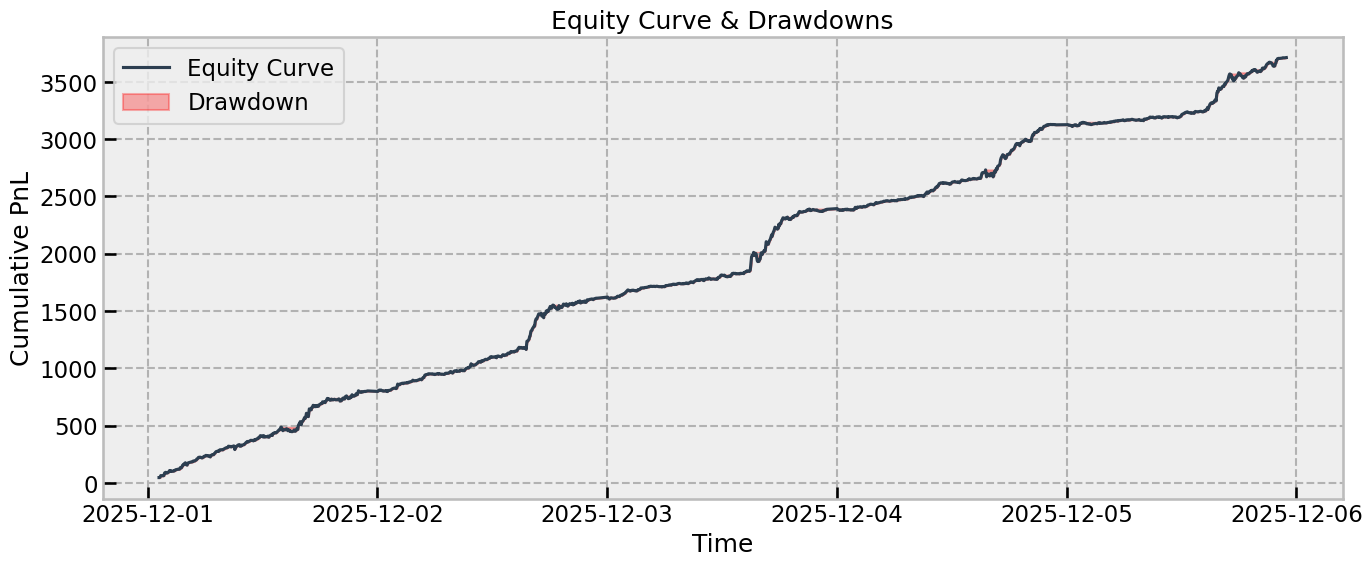

In [134]:
trades_df['Equity'] = trades_df['PnL'].cumsum()
trades_df['Roll_Max'] = trades_df['Equity'].cummax()
trades_df['Drawdown'] = trades_df['Equity'] - trades_df['Roll_Max']

plt.figure(figsize=(16,6))
plt.plot(trades_df['Exit_Time'], trades_df['Equity'], label='Equity Curve', color='#2c3e50')
plt.fill_between(trades_df['Exit_Time'], trades_df['Equity'], trades_df['Roll_Max'], color='red', alpha=0.3, label='Drawdown')
plt.title("Equity Curve & Drawdowns")
plt.xlabel("Time")
plt.ylabel("Cumulative PnL")
plt.legend()
plt.grid(True)
plt.show()

#### Hourly Performance

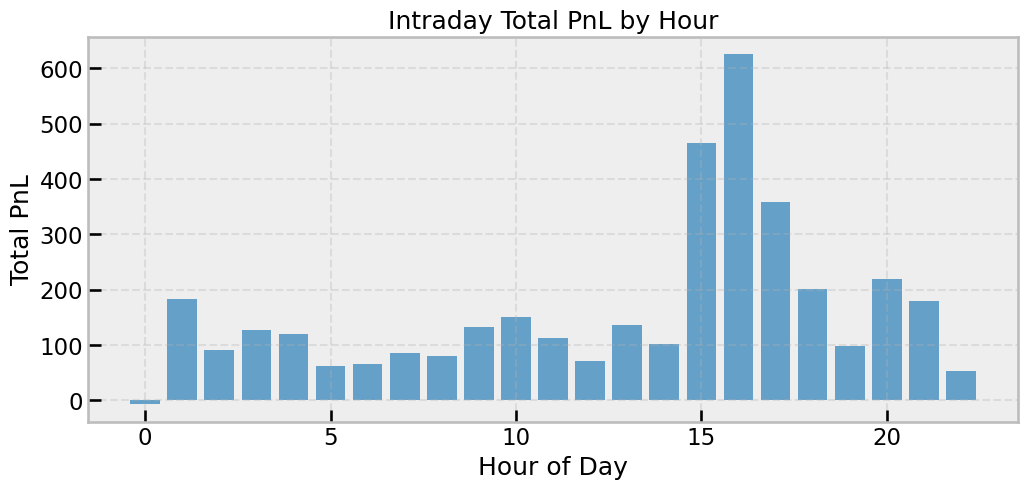

In [135]:
trades_df['Hour'] = trades_df['Entry_Time'].dt.hour
hourly_perf = trades_df.groupby('Hour')['PnL'].agg(['count','sum','mean']).reset_index()

plt.figure(figsize=(12,5))
plt.bar(hourly_perf['Hour'], hourly_perf['sum'], color='#2980b9', alpha=0.7)
plt.title("Intraday Total PnL by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Total PnL")
plt.grid(alpha=0.3)
plt.show()

#### PnL Distribution

In [ ]:
if not trades_df.empty:
    plt.figure(figsize=(12,6))
    sns.histplot(trades_df['Points'], bins=50, kde=True, color='#3498db', alpha=0.7)
    plt.title('PnL Distribution of Trades', fontsize=16)
    plt.xlabel('Points per Trade')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    plt.show()

#### Performance by Exit Reason

In [ ]:
if not trades_df.empty:
    plt.figure(figsize=(12,6))
    sns.boxplot(x='Reason', y='Points', data=trades_df, palette='Set2')
    plt.title('Trade Performance by Exit Reason', fontsize=16)
    plt.xlabel('Exit Reason')
    plt.ylabel('Points')
    plt.grid(True, alpha=0.3)
    plt.show()

#### Intraday (Hourly) Performance Analysis

In [ ]:
if not trades_df.empty:
    trades_df['Hour'] = pd.to_datetime(trades_df['Entry Time']).dt.hour
    hourly_stats = trades_df.groupby('Hour').agg(
        total_pnl=('Points', 'sum'),
        avg_pnl=('Points', 'mean'),
        trade_count=('Points', 'count')
    ).reset_index()

    # Plot total PnL by hour
    plt.figure(figsize=(14,5))
    colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in hourly_stats['total_pnl']]
    plt.bar(hourly_stats['Hour'], hourly_stats['total_pnl'], color=colors, edgecolor='black', alpha=0.8)
    plt.title('Total PnL by Hour of Day', fontsize=16)
    plt.xlabel('Hour')
    plt.ylabel('Total Points')
    plt.axhline(0, color='black')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    # Plot average PnL per trade by hour
    plt.figure(figsize=(14,5))
    sns.lineplot(x='Hour', y='avg_pnl', data=hourly_stats, marker='o', color='#e67e22')
    plt.title('Average PnL per Trade by Hour', fontsize=16)
    plt.xlabel('Hour')
    plt.ylabel('Average Points')
    plt.grid(True, alpha=0.3)
    plt.show()

    # Plot trade count by hour
    plt.figure(figsize=(14,5))
    sns.barplot(x='Hour', y='trade_count', data=hourly_stats, color='#9b59b6', alpha=0.8)
    plt.title('Number of Trades by Hour of Day', fontsize=16)
    plt.xlabel('Hour')
    plt.ylabel('Trade Count')
    plt.grid(True, alpha=0.3)
    plt.show()

#### Advanced 3D Trade Surface

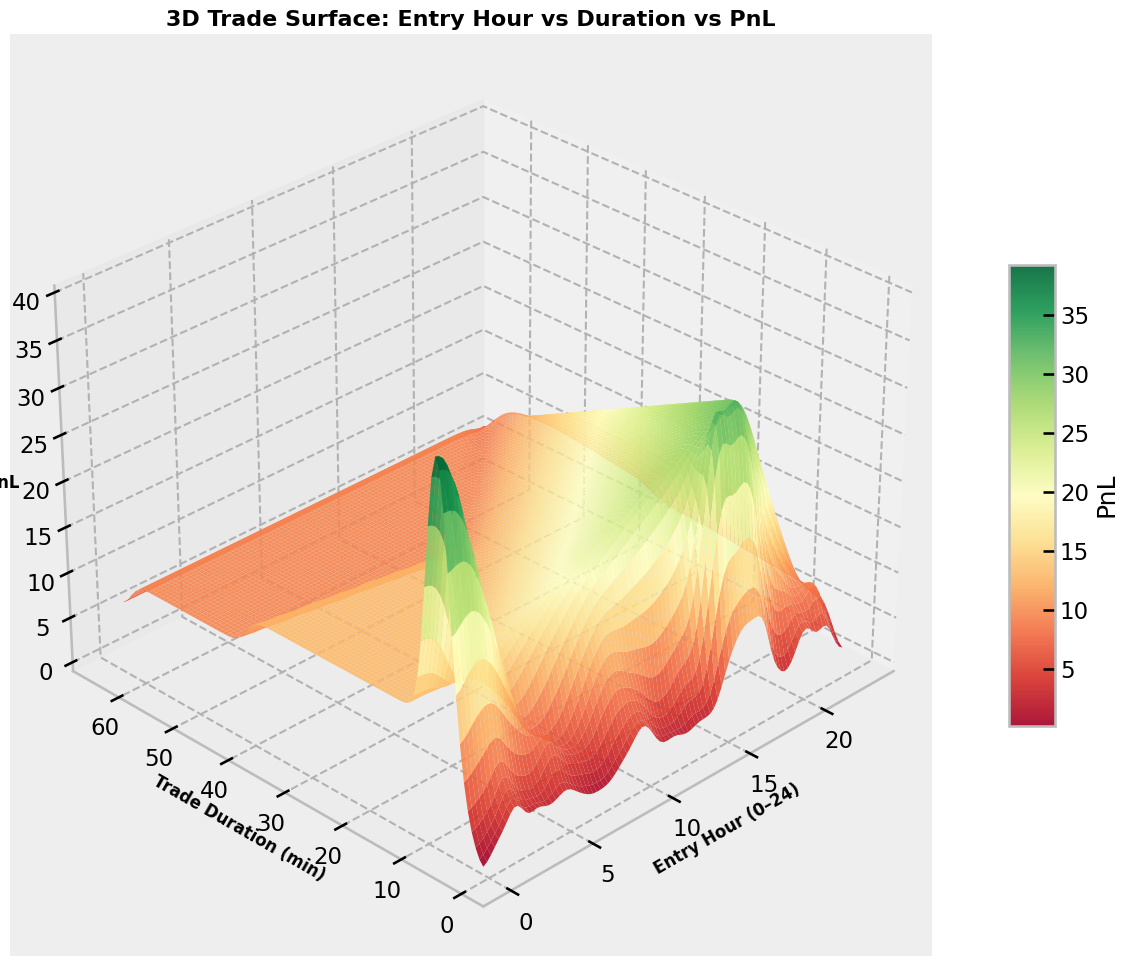

In [138]:
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for 3D surface
df_3d = trades_df.copy()
df_3d['Entry_Time'] = pd.to_datetime(df_3d['Entry_Time'])
df_3d['Hour_Float'] = df_3d['Entry_Time'].dt.hour + df_3d['Entry_Time'].dt.minute / 60.0

x = df_3d['Hour_Float']          # Entry time in hours
y = df_3d['Duration_min']        # Trade duration in minutes
z = df_3d['PnL']                 # Trade PnL

# Create interpolation grid
xi = np.linspace(x.min(), x.max(), 100)
yi = np.linspace(y.min(), y.max(), 100)
xi, yi = np.meshgrid(xi, yi)

# Interpolate and smooth the surface
zi = griddata((x, y), z, (xi, yi), method='linear')
zi_nearest = griddata((x, y), z, (xi, yi), method='nearest')
zi[np.isnan(zi)] = zi_nearest[np.isnan(zi)]
zi_smooth = gaussian_filter(zi, sigma=2)

# Plot 3D surface
fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    xi, yi, zi_smooth, 
    cmap='RdYlGn', 
    antialiased=True, 
    alpha=0.9, 
    rstride=1, 
    cstride=1
)

# Professional labeling and formatting
ax.set_title('3D Trade Surface: Entry Hour vs Duration vs PnL', fontsize=16, weight='bold')
ax.set_xlabel('Entry Hour (0–24)', fontsize=12, weight='bold')
ax.set_ylabel('Trade Duration (min)', fontsize=12, weight='bold')
ax.set_zlabel('PnL', fontsize=12, weight='bold')
ax.view_init(elev=30, azim=225)

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='PnL')

plt.tight_layout()
plt.show()


## 3.7 Baseline Strategy Evaluation

### **A. Market Regime Analysis**
- **Non-stationary BTC–NQ relationship:** Correlation varies across market regimes.
- **Event-Driven Synchronization:** Rolling correlations spike (>0.7) around **NY Market Open (15:30 CET)**, confirming high-volume events drive asset synchronization.
- **Golden Hours:** Hourly heatmap identifies **15:00–17:00 CET** as stable positive correlation windows, optimal for cross-asset signals.

### **B. Strategy Performance (Backtest)**
- **Profitability Drivers:** Alpha is mainly captured during high-correlation windows.  
- **Drawdown Periods:** Losses occur when correlation weakens, e.g., London lunch lull (12:00–14:00) and late NY session.  
- **Transaction Costs & Trade Frequency:** ~2800 trades, many ultra-short (0–1 min), could erode net returns once fees/slippage are applied. Strategy needs filtering for higher-quality trades.

### **C. Advanced Optimization Insights (3D Analysis)**
- **High-probability sessions:** Most profitable trades cluster in **NY session**, minor cluster at Asian session open (requires more data).  
- **Trade Duration:** Short trades (0–3 min) are mostly unprofitable; filtering these could reduce losses.

## 3.8 Motivation for Machine Learning Enhancement

The backtesting and microstructure analysis highlight opportunities for improving strategy performance using machine learning:

- **Time-Filtering Optimization:** ML models can dynamically identify high-probability trading windows (e.g., "golden hours") instead of using fixed hours.  
- **Feature-Based Signal Enhancement:** Incorporating additional features such as `Rolling_Corr_60m`, Bollinger Bands, volatility measures, or other microstructure indicators can allow ML algorithms to filter low-quality trades and improve predictive accuracy.  
- **Trade Quality Prediction:** ML can help predict which signals are likely to be profitable, reducing the frequency of ultra-short, unprofitable trades.  
- **Adaptive Strategy:** Machine learning enables the strategy to adjust to non-stationary market regimes, capturing evolving correlations between BTC and NQ.


# 4. Modelling

## 4.1 Split Data in Training and Testing Set
## 4.2 Select Suitable Modeling Techniques
## 4.3 Generate Test Design
## 4.4 Apply Selected Modeling Techniques
## 4.5 Assess Model

# 5. Evaluation

## 5.1 Apply Test Set
## 5.2 Interpret Result
## 5.3 Cross-Check Results
## 5.4 Final Model Training
## 5.5 Review Process
## 5.6 Interpret Results